In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ev_charging_patterns[1].csv to ev_charging_patterns[1].csv


In [ ]:
df.to_csv('ev_charging_patterns_cleaned.csv', index=False)

In [ ]:
from google.colab import files

files.download('ev_charging_patterns_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

df = pd.read_csv('ev_charging_patterns[1].csv')

df.head()

,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,13.087717,Evening,Tuesday,29.371576,86.119962,293.602111,27.947953,2.0,DC Fast Charger,Commuter
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,21.128448,Morning,Monday,10.115778,84.664344,112.112804,14.311026,3.0,Level 1,Casual Driver
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,35.667270,Morning,Thursday,6.854604,69.917615,71.799253,21.002002,2.0,Level 2,Commuter
3,User_4,Hyundai Kona,50.000000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.457824,1.266431,32.882870,13.036239,Evening,Saturday,83.120003,99.624328,199.577785,38.316313,1.0,Level 1,Long-Distance Traveler
4,User_5,Hyundai Kona,50.000000,Station_108,Los Angeles,2024-01-01 04:00:00,2024-01-01 05:46:00,19.629104,2.019765,10.215712,10.161471,Morning,Saturday,54.258950,63.743786,203.661847,-7.834199,1.0,Level 1,Long-Distance Traveler


In [ ]:
df.columns

Index(['User ID', 'Vehicle Model', 'Battery Capacity (kWh)',
       'Charging Station ID', 'Charging Station Location',
       'Charging Start Time', 'Charging End Time', 'Energy Consumed (kWh)',
       'Charging Duration (hours)', 'Charging Rate (kW)',
       'Charging Cost (USD)', 'Time of Day', 'Day of Week',
       'State of Charge (Start %)', 'State of Charge (End %)',
       'Distance Driven (since last charge) (km)', 'Temperature (°C)',
       'Vehicle Age (years)', 'Charger Type', 'User Type'],
      dtype='object')

In [ ]:
X = df[
    [
        'Battery Capacity (kWh)',
        'Charging Duration (hours)',
        'Charging Rate (kW)',
        'Temperature (°C)',
        'Vehicle Age (years)',
        'Distance Driven (since last charge) (km)'
    ]
]

y = df['Energy Consumed (kWh)']

print(X.shape)
print(y.shape)

(1320, 6)
(1320,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1056, 6)
(264, 6)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Drop rows where y is NaN from both X and y
# This ensures that X and y have corresponding rows and no NaNs in the target.
df_cleaned = df.dropna(subset=['Energy Consumed (kWh)'])

# Re-define X and y with the cleaned DataFrame
X = df_cleaned[
    [
        'Battery Capacity (kWh)',
        'Charging Duration (hours)',
        'Charging Rate (kW)',
        'Temperature (°C)',
        'Vehicle Age (years)',
        'Distance Driven (since last charge) (km)'
    ]
]
y = df_cleaned['Energy Consumed (kWh)']

# Re-split the data after cleaning
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 18.282445724041626
R2 Score: -0.025985112083256823


In [ ]:
print("MAE:", mae)
print("R2 Score:", r2)

MAE: 18.282445724041626
R2 Score: -0.025985112083256823


# Model Results

A Random Forest Regressor was trained to predict energy consumption during EV charging sessions.

Results:
- Mean Absolute Error (MAE): 18.28 kWh
- R² Score: -0.026

The model achieved limited predictive performance due to weak relationships among the available features. This suggests that energy consumption is influenced by additional factors not fully captured in the dataset.

Future improvements could include:
- Additional historical charging data
- User behavior features
- Geographic and traffic-related variables
- Advanced feature engineering

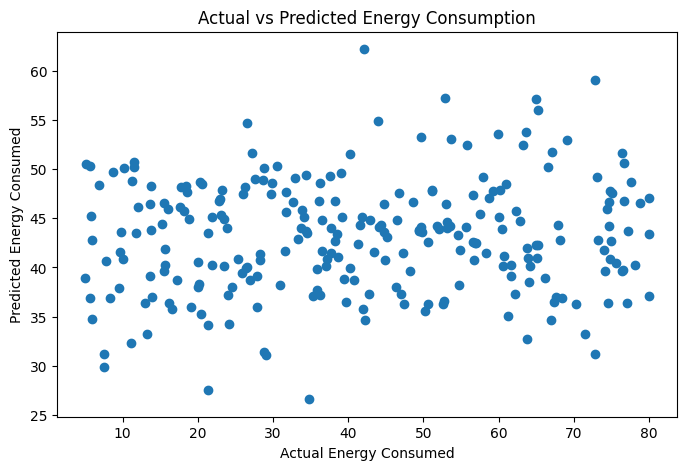

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Energy Consumed')
plt.ylabel('Predicted Energy Consumed')
plt.title('Actual vs Predicted Energy Consumption')
plt.show()

### Model Evaluation

The Actual vs Predicted Energy Consumption plot shows that predictions are concentrated around the average energy consumption values rather than closely matching the actual observations.

This behavior is consistent with the obtained R² score of -0.026, indicating that the available features have limited predictive power for estimating energy consumption. Future improvements may include incorporating additional behavioral, geographic, and temporal features.

```
`# This is formatted as code`
```

